In [1]:
# Colab / fresh environment: install the module (builds the C++ core, takes a few minutes the first time)
try:
    import sensor_fusion
except ImportError:
    %pip install -q git+https://github.com/Rudip1/learn-sensor-fusion

# 1 · GNSS fundamentals: how a fix is computed and how it is reported

**Recap** ([theory](../../1_theory/01_gnss_fundamentals.md)). A receiver measures *pseudoranges*
$\rho_i = \lVert\mathbf s_i-\mathbf r\rVert + b + \varepsilon_i$ (1.1): true ranges plus its own clock offset
$b=c\,\delta t_r$. Four unknowns $(\mathbf r, b)$ need four satellites; the non-linear system is solved by
Gauss–Newton with the geometry matrix $\mathbf G$ of rows $[-\mathbf u_i^\top\ 1]$ (1.2)–(1.3), and
$(\mathbf G^\top\mathbf G)^{-1}$ scales the noise into the position (1.4).
The receiver reports the result as NMEA 0183 text: `$`, talker + type, comma-separated fields, `*` and an
XOR checksum (1.6). Angles are `ddmm.mmmm` (1.7), GGA heights are above the geoid (1.8), speeds in knots (1.9).

In this notebook you decode the two recorded logs with the C++ parser, re-implement the checksum and the
angle conversion, write a Gauss–Newton step yourself, and then break the assumptions.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sensor_fusion as sf
from sensor_fusion import gnss, nmea
from sensor_fusion.plotting import SERIES, use_style

use_style()

## 1. One sentence, by hand and by the parser

The worked example of the theory chapter:

In [3]:
line = "$GPGGA,091509.000,4728.4639,N,01903.4171,E,1,7,1.55,105.5,M,41.1,M,,*52"
split = nmea.split(line)
print(split.status, split.sentence)
print("fields:", split.sentence.fields)

gga = nmea.parse_gga(split.sentence)
print(f"time of day  {gga.time_of_day_s:.0f} s after UTC midnight")
print(f"latitude     {gga.latitude_deg:.9f} deg")
print(f"longitude    {gga.longitude_deg:.9f} deg")
print(f"H (MSL)      {gga.altitude_msl_m} m, geoid N_g {gga.geoid_separation_m} m -> h = {gga.altitude_msl_m + gga.geoid_separation_m:.1f} m  (1.8)")
print(f"checksum     0x{nmea.checksum(line[1:line.index('*')]):02X}")

Status.ok <Sentence GPGGA with 14 fields>
fields: ['091509.000', '4728.4639', 'N', '01903.4171', 'E', '1', '7', '1.55', '105.5', 'M', '41.1', 'M', '', '']
time of day  33309 s after UTC midnight
latitude     47.474398333 deg
longitude    19.056951667 deg
H (MSL)      105.5 m, geoid N_g 41.1 m -> h = 146.6 m  (1.8)
checksum     0x52


### ✏️ Exercise 1 — the checksum

Write `my_checksum(line)` that takes a **complete** sentence such as the one above and returns the
checksum computed from its body as an integer (eq. 1.6). The check cell compares it with the transmitted
value on every line of both recorded logs.

In [4]:
def my_checksum(line: str) -> int:
    ### BEGIN SOLUTION
    body = line[line.index("$") + 1 : line.index("*")]
    c = 0
    for ch in body:
        c ^= ord(ch)
    return c
    ### END SOLUTION

In [5]:
n_checked = 0
for name in ["nmea_log1.nmea", "nmea_log2.nmea"]:
    for raw in open(sf.data.path("gnss/" + name)):
        raw = raw.strip()
        assert my_checksum(raw) == int(raw.split("*")[1], 16), raw
        n_checked += 1
print(f"✅ checksum matches on all {n_checked} lines")

✅ checksum matches on all 2608 lines


### ✏️ Exercise 2 — degrees and decimal minutes

Write `ddmm_to_deg(value, hemisphere)` implementing eq. (1.7) on strings, e.g.
`ddmm_to_deg("01903.4171", "E") -> 19.05695166…`. Return `None` for empty fields.
Then compute how far off a position would be if `4728.4639` were misread as 47.284639°
(use 111.2 km per degree of latitude).

In [6]:
def ddmm_to_deg(value: str, hemisphere: str):
    ### BEGIN SOLUTION
    if not value or not hemisphere:
        return None
    v = float(value)
    degrees = int(v // 100)
    angle = degrees + (v - 100 * degrees) / 60.0
    return -angle if hemisphere in ("S", "W") else angle
    ### END SOLUTION


### BEGIN SOLUTION
misread_error_km = abs(ddmm_to_deg("4728.4639", "N") - 47.284639) * 111.2
### END SOLUTION
print(f"misreading ddmm as decimal degrees: {misread_error_km:.1f} km off")

misreading ddmm as decimal degrees: 21.1 km off


In [7]:
for raw in open(sf.data.path("gnss/nmea_log2.nmea")):
    s = nmea.split(raw).sentence
    if s.type == "GGA":
        f = s.fields
        assert abs(ddmm_to_deg(f[1], f[2]) - nmea.parse_angle(f[1], f[2])) < 1e-12
        assert abs(ddmm_to_deg(f[3], f[4]) - nmea.parse_angle(f[3], f[4])) < 1e-12
assert ddmm_to_deg("", "N") is None
assert ddmm_to_deg("3330.0000", "S") == -33.5
assert 20 < misread_error_km < 22
print("✅ angle conversion agrees with the C++ parser")

✅ angle conversion agrees with the C++ parser


## 2. Decoding the recorded logs

Two logs from a consumer receiver: `nmea_log1.nmea` and `nmea_log2.nmea`. `parse_log_file` runs
Algorithm 1.2 and groups the sentences into epochs.

In [8]:
logs, dates = {}, {}
for name in ["nmea_log1.nmea", "nmea_log2.nmea"]:
    log = nmea.parse_log_file(str(sf.data.path("gnss/" + name)))
    logs[name] = sf.tables.epochs_to_arrays(log.epochs)
    dates[name] = log.epochs[-1].date
    st = log.stats
    print(f"{name}: {st.lines} lines, {st.sentences} valid, {st.checksum_errors} checksum errors, "
          f"{len(log.epochs)} epochs, types {dict(st.counts_by_type)}")

for name, a in logs.items():
    valid = a["fix_quality"] > 0
    print(f"{name}: {valid.sum()} epochs with a fix, date {dates[name]}, "
          f"satellites used {a['sats_used'].min()}..{a['sats_used'].max()}, "
          f"median HDOP {np.nanmedian(a['hdop'][valid]):.2f}, median speed {np.nanmedian(a['speed'][valid]):.2f} m/s")

nmea_log1.nmea: 1040 lines, 1040 valid, 0 checksum errors, 231 epochs, types {'GGA': 231, 'GSA': 231, 'GSV': 116, 'RMC': 231, 'VTG': 231}
nmea_log2.nmea: 1568 lines, 1568 valid, 0 checksum errors, 327 epochs, types {'GGA': 327, 'GSA': 327, 'GSV': 260, 'RMC': 327, 'VTG': 327}
nmea_log1.nmea: 219 epochs with a fix, date 2025-11-04, satellites used 2..5, median HDOP 2.17, median speed 0.19 m/s
nmea_log2.nmea: 327 epochs with a fix, date 2025-11-04, satellites used 6..7, median HDOP 1.56, median speed 1.13 m/s


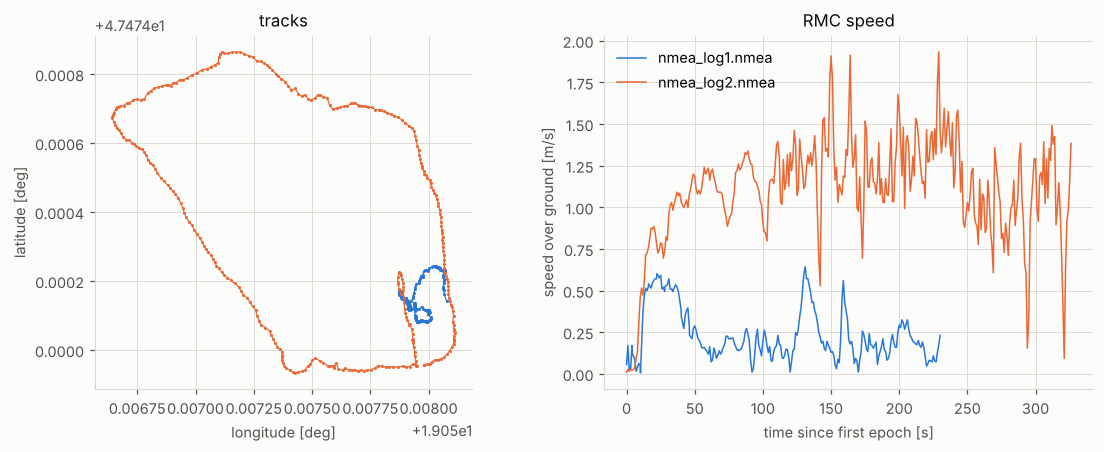

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for (name, a), color in zip(logs.items(), SERIES):
    valid = a["fix_quality"] > 0
    axes[0].plot(a["lon"][valid], a["lat"][valid], ".-", ms=2, lw=0.8, color=color, label=name)
    axes[1].plot(a["t"] - a["t"][0], a["speed"], lw=1, color=color, label=name)
# one degree of longitude is cos(lat) times shorter than one of latitude: correct the aspect ratio
axes[0].set_aspect(1 / np.cos(np.radians(47.47)))
axes[0].set_xlabel("longitude [deg]"); axes[0].set_ylabel("latitude [deg]"); axes[0].set_title("tracks")
axes[1].set_xlabel("time since first epoch [s]"); axes[1].set_ylabel("speed over ground [m/s]")
axes[1].set_title("RMC speed"); axes[1].legend()
plt.show()

The first log stays inside a small cluster with a speed that is mostly receiver noise; the second
traces a loop at walking speed. Chapter 3 turns this impression into a test.

The first epochs of log 1 have no fix. Look at what the parser reports there:

In [10]:
e0 = nmea.parse_log_file(str(sf.data.path("gnss/nmea_log1.nmea"))).epochs[0]
print("fix quality", e0.fix_quality, "| latitude", e0.latitude_deg, "| fix type", e0.fix_type,
      "| satellites used", e0.satellites_used)

fix quality 0 | latitude None | fix type 1 | satellites used 2


`None`, not `0.0`: an empty field is *no value*. Plotting this epoch as (0°, 0°) would be the classic
"Null Island" bug.

## 3. Computing a fix from pseudoranges

We simulate a receiver at 47.47° N, 19.06° E on a spherical Earth, eight satellites at chosen
azimuths/elevations (eq. 1.5), a receiver clock offset of 1 ms and 3 m pseudorange noise.

In [11]:
c = gnss.SPEED_OF_LIGHT
print(f"1 µs of clock offset = {c * 1e-6:.1f} m of range")

lat, lon, R_earth = np.radians(47.47), np.radians(19.06), 6_371_000.0
r_true = R_earth * np.array([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)])
az = np.radians([20, 70, 115, 160, 210, 250, 300, 340])
el = np.radians([65, 30, 45, 15, 55, 25, 40, 12])
sats = gnss.place_satellites(r_true, az, el)
b_true = 1e-3 * c
rng = np.random.default_rng(0)
rho = gnss.geometric_ranges(r_true, sats) + b_true + rng.normal(0, 3.0, len(az))

sol = gnss.solve_position(sats, rho)
print(f"converged={sol.converged} in {sol.iterations} iterations")
print(f"position error {np.linalg.norm(sol.position - r_true):.2f} m, clock bias {sol.clock_bias_m / c * 1e3:.6f} ms")
print("residuals [m]:", np.round(sol.residuals, 2))

1 µs of clock offset = 299.8 m of range
converged=True in 5 iterations
position error 2.32 m, clock bias 1.000007 ms
residuals [m]: [-0.5  -1.28  2.06  0.29 -1.75 -0.44  1.95 -0.32]


### ✏️ Exercise 3 — Gauss–Newton yourself

Implement `gauss_newton(sats, rho, iterations)` in numpy: start at $\mathbf x=\mathbf 0$, build
$\mathbf G$ (1.2) and $\Delta\boldsymbol\rho$, solve the normal equations (1.3), update. Return
`(r, b)`. The check compares with the C++ solver.

In [12]:
def gauss_newton(sats: np.ndarray, rho: np.ndarray, iterations: int = 10):
    ### BEGIN SOLUTION
    x = np.zeros(4)
    for _ in range(iterations):
        diff = sats - x[:3]
        ranges = np.linalg.norm(diff, axis=1)
        u = diff / ranges[:, None]
        G = np.hstack([-u, np.ones((len(rho), 1))])
        dx = np.linalg.solve(G.T @ G, G.T @ (rho - (ranges + x[3])))
        x += dx
    return x[:3], x[3]
    ### END SOLUTION

In [13]:
r_mine, b_mine = gauss_newton(sats, rho)
assert np.linalg.norm(r_mine - sol.position) < 1e-4
assert abs(b_mine - sol.clock_bias_m) < 1e-4
G = gnss.geometry_matrix(sol.position, sats)
assert np.allclose(np.linalg.inv(G.T @ G), sol.cofactor, rtol=1e-6)
print("✅ your Gauss-Newton matches the C++ solver")

✅ your Gauss-Newton matches the C++ solver


## 4. 🔨 Break it

### 🔨 4.1 Skip the checksum
Change one digit of the latitude. With the checksum the sentence is rejected; without it the wrong
position is accepted silently.

In [14]:
bad = line.replace("4728.4639", "4728.4689")
print("with checksum   :", nmea.split(bad).status)
# the line still *has* a checksum, so strip it to mimic a parser that ignores it
s = nmea.split(bad.split("*")[0], require_checksum=False)
moved = (nmea.parse_gga(s.sentence).latitude_deg - gga.latitude_deg) * 111_200
print(f"without checksum: {s.status}, latitude silently moved by {moved:.1f} m")

with checksum   : Status.checksum_mismatch
without checksum: Status.ok, latitude silently moved by 9.3 m


### 🔨 4.2 Forget the receiver clock
Solve for position only (three unknowns) as if $b=0$. The clock offset has nowhere to go but into the
position.

In [15]:
def gauss_newton_no_clock(sats, rho, iterations=20):
    r = np.zeros(3)
    for _ in range(iterations):
        diff = sats - r
        ranges = np.linalg.norm(diff, axis=1)
        G = -diff / ranges[:, None]
        r += np.linalg.lstsq(G, rho - ranges, rcond=None)[0]
    return r

for offset_us in [0.0, 0.1, 1.0, 10.0]:
    rho_k = gnss.geometric_ranges(r_true, sats) + offset_us * 1e-6 * c
    err = np.linalg.norm(gauss_newton_no_clock(sats, rho_k) - r_true)
    print(f"clock offset {offset_us:5.1f} µs -> position error {err:12.1f} m")

clock offset   0.0 µs -> position error          0.0 m
clock offset   0.1 µs -> position error         45.5 m
clock offset   1.0 µs -> position error        455.0 m
clock offset  10.0 µs -> position error       4550.1 m


### 🔨 4.3 Bad geometry
Same noise, but all satellites squeezed into one part of the sky. The cofactor matrix (1.4) grows and
the error with it — the subject of chapter 3 (DOP).

In [16]:
def monte_carlo(az, el, trials=300, sigma=3.0):
    s = gnss.place_satellites(r_true, az, el)
    clean = gnss.geometric_ranges(r_true, s) + b_true
    errs = [np.linalg.norm(gnss.solve_position(s, clean + rng.normal(0, sigma, len(az))).position - r_true)
            for _ in range(trials)]
    return np.sqrt(np.mean(np.square(errs))), s

good_rms, _ = monte_carlo(az, el)
az_bad = np.radians([80, 90, 100, 110, 85, 95, 105, 115])
el_bad = np.radians([30, 40, 35, 45, 50, 38, 42, 33])
bad_rms, sats_bad = monte_carlo(az_bad, el_bad)
print(f"RMS 3D error, spread sky   : {good_rms:7.1f} m")
print(f"RMS 3D error, clustered sky: {bad_rms:7.1f} m")
Gb = gnss.geometry_matrix(r_true, sats_bad)
print("sqrt(trace Q) spread vs clustered:",
      round(float(np.sqrt(np.trace(np.linalg.inv(G.T @ G)[:3, :3]))), 2),
      round(float(np.sqrt(np.trace(np.linalg.inv(Gb.T @ Gb)[:3, :3]))), 2))

RMS 3D error, spread sky   :     5.2 m
RMS 3D error, clustered sky:    68.3 m
sqrt(trace Q) spread vs clustered: 1.74 23.76


### 🔨 4.4 Three satellites
Three equations, four unknowns: the normal matrix is singular and the solver refuses.

In [17]:
sol3 = gnss.solve_position(sats[:3], rho[:3])
print("converged with 3 satellites:", sol3.converged)

converged with 3 satellites: False


## What to remember

- A pseudorange is a range **plus the receiver clock bias**; the bias is the fourth unknown, so a 3D fix
  needs four satellites.
- Positioning is a non-linear least-squares problem; Gauss–Newton converges from the Earth's centre in a
  handful of iterations, and $(\mathbf G^\top\mathbf G)^{-1}$ maps range noise into position noise.
- NMEA fields are optional: an empty field is *no value*; check fix quality / status before using a position.
- Convert `ddmm.mmmm` with (1.7), apply the hemisphere sign, and use $h = H + N_g$ for geodetic work.
- Verify the checksum; a single flipped digit otherwise moves you silently.